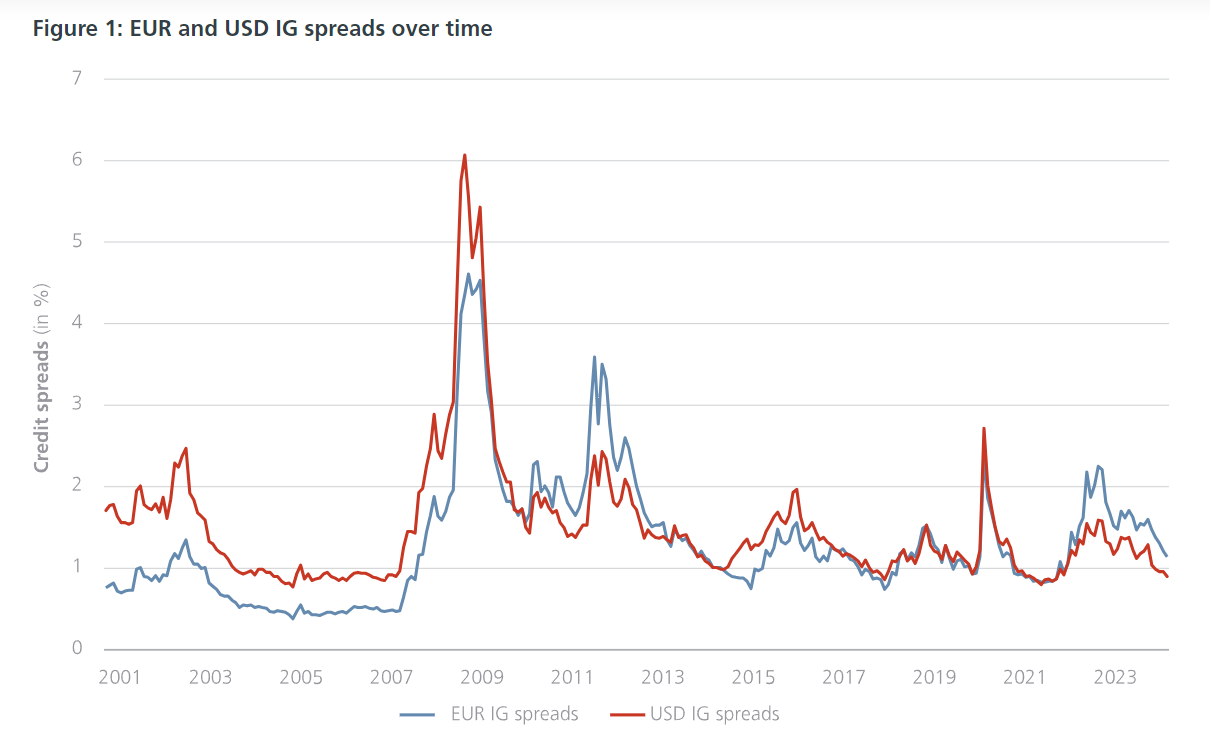

In [ ]:
!pip install fredapi > /dev/null

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from fredapi import Fred
from scipy.integrate import quad
from scipy.optimize import minimize
from datetime import datetime as dt

#from nelson_siegel_svensson import NelsonSiegelSvenssonCurve
#from nelson_siegel_svensson.calibrate import calibrate_nss_ols
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
fred_key = "53917613661bf2de6cc1184fed44e685"
fred= Fred(api_key = fred_key)

In [ ]:
def fred_query(list_name, dict_name, start):
  all_results = []
  #Durch Liste loopen, alle Zeitreihen aus FRED ziehen & in df temporär speichern
  for myid in list_name:
    results = fred.get_series(myid,start)
    results = results.to_frame(name=myid)
    all_results.append(results)
  #Alle dataframes zusammenpacken und dann gemäß Dict umbennen
  df_fred_results = pd.concat(all_results,axis =1)
  df_fred_results.columns= [dict_name[c] for c in df_fred_results.columns]

  return df_fred_results

In [ ]:
ICE_Bofa_USD_id = ["BAMLHYH0A0HYM2TRIV","BAMLH0A0HYM2","BAMLH0A0HYM2SYTW","BAMLCC0A0CMTRIV","BAMLC0A0CM","BAMLC0A0CMSYTW","BAMLCC0A1AAATRIV","BAMLC0A1CAAA","BAMLC0A1CAAASYTW","BAMLCC0A2AATRIV","BAMLC0A2CAA","BAMLC0A2CAASYTW","BAMLCC0A3ATRIV","BAMLC0A3CA","BAMLC0A3CASYTW","BAMLCC0A4BBBTRIV","BAMLC0A4CBBB","BAMLC0A4CBBBSYTW","BAMLHYH0A1BBTRIV","BAMLH0A1HYBB","BAMLH0A1HYBBSYTW","BAMLHYH0A2BTRIV","BAMLH0A2HYB","BAMLH0A2HYBSYTW","BAMLHYH0A3CMTRIV","BAMLH0A3HYC","BAMLH0A3HYCSYTW","BAMLCC1A013YTRIV","BAMLC1A0C13Y","BAMLC1A0C13YSYTW","BAMLCC2A035YTRIV","BAMLC2A0C35Y","BAMLC2A0C35YSYTW","BAMLCC3A057YTRIV","BAMLC3A0C57Y","BAMLC3A0C57YSYTW","BAMLCC4A0710YTRIV","BAMLC4A0C710Y","BAMLC4A0C710YSYTW","BAMLCC7A01015YTRIV","BAMLC7A0C1015Y","BAMLC7A0C1015YSYTW","BAMLCC8A015PYTRIV","BAMLC8A0C15PY","BAMLC8A0C15PYSYTW"]
ICE_Bofa_USD_dict = {"BAMLHYH0A0HYM2TRIV":"ICE_Bofa_US_High_Yield_TR_Index","BAMLH0A0HYM2":"ICE_Bofa_US_High_Yield_OAS","BAMLH0A0HYM2SYTW":"ICE_Bofa_US_High_Yield_YTW",
                     "BAMLCC0A0CMTRIV":"ICE_Bofa_US_Corp_TR_Index","BAMLC0A0CM":"ICE_Bofa_US_Corp_OAS","BAMLC0A0CMSYTW":"ICE_Bofa_US_Corp_YTW",
                     "BAMLCC0A1AAATRIV":"ICE_Bofa_US_AAA_TR_Index","BAMLC0A1CAAA":"ICE_Bofa_US_AAA_OAS","BAMLC0A1CAAASYTW":"ICE_Bofa_US_AAA_YTW",
                     "BAMLCC0A2AATRIV":"ICE_Bofa_US_AA_TR_Index","BAMLC0A2CAA":"ICE_Bofa_US_AA_OAS","BAMLC0A2CAASYTW":"ICE_Bofa_US_AA_YTW",
                     "BAMLCC0A3ATRIV":"ICE_Bofa_US_A_TR_Index","BAMLC0A3CA":"ICE_Bofa_US_A_OAS","BAMLC0A3CASYTW":"ICE_Bofa_US_A_YTW",
                     "BAMLCC0A4BBBTRIV":"ICE_Bofa_US_BBB_TR_Index","BAMLC0A4CBBB":"ICE_Bofa_US_BBB_OAS","BAMLC0A4CBBBSYTW":"ICE_Bofa_US_BBB_YTW",
                     "BAMLHYH0A1BBTRIV":"ICE_Bofa_US_BB_TR_Index","BAMLH0A1HYBB":"ICE_Bofa_US_BB_OAS","BAMLH0A1HYBBSYTW":"ICE_Bofa_US_BB_YTW",
                     "BAMLHYH0A2BTRIV":"ICE_Bofa_US_B_TR_Index","BAMLH0A2HYB":"ICE_Bofa_US_B_OAS","BAMLH0A2HYBSYTW":"ICE_Bofa_US_B_YTW",
                     "BAMLHYH0A3CMTRIV":"ICE_Bofa_US_CCC_TR_Index","BAMLH0A3HYC":"ICE_Bofa_US_CCC_OAS","BAMLH0A3HYCSYTW":"ICE_Bofa_US_CCC_YTW",
                     "BAMLCC1A013YTRIV":"ICE_Bofa_US_1_3_TR_Index","BAMLC1A0C13Y":"ICE_Bofa_US_1_3_OAS","BAMLC1A0C13YSYTW":"ICE_Bofa_US_1_3_YTW",
                     "BAMLCC2A035YTRIV":"ICE_Bofa_US_3_5_TR_Index","BAMLC2A0C35Y":"ICE_Bofa_US_3_5_OAS","BAMLC2A0C35YSYTW":"ICE_Bofa_US_3_5_YTW",
                     "BAMLCC3A057YTRIV":"ICE_Bofa_US_5_7_TR_Index","BAMLC3A0C57Y":"ICE_Bofa_US_5_7_OAS","BAMLC3A0C57YSYTW":"ICE_Bofa_US_5_7_YTW",
                     "BAMLCC4A0710YTRIV":"ICE_Bofa_US_7_10_TR_Index","BAMLC4A0C710Y":"ICE_Bofa_US_7_10_OAS","BAMLC4A0C710YSYTW":"ICE_Bofa_US_7_10_YTW",
                     "BAMLCC7A01015YTRIV":"ICE_Bofa_US_10_15_TR_Index","BAMLC7A0C1015Y":"ICE_Bofa_US_10_15_OAS","BAMLC7A0C1015YSYTW":"ICE_Bofa_US_10_15_YTW",
                     "BAMLCC8A015PYTRIV":"ICE_Bofa_US_15+_TR_Index","BAMLC8A0C15PY":"ICE_Bofa_US_15+_OAS","BAMLC8A0C15PYSYTW":"ICE_Bofa_US_15+_YTW"}

ICE_Bofa_USD_rating_id = ["BAMLH0A0HYM2SYTW","BAMLC0A0CMSYTW","BAMLC0A1CAAASYTW","BAMLC0A2CAASYTW","BAMLC0A3CASYTW", "BAMLC0A4CBBBSYTW","BAMLH0A1HYBBSYTW","BAMLH0A2HYBSYTW"]
ICE_Bofa_USD_rating_dict = {"BAMLH0A0HYM2SYTW":"US_High_Yield", "BAMLC0A0CMSYTW":"US_Corp",
                            "BAMLC0A1CAAASYTW":"US_AAA","BAMLC0A2CAASYTW":"US_AA","BAMLC0A3CASYTW":"US_A",
                            "BAMLC0A4CBBBSYTW":"US_BBB","BAMLH0A1HYBBSYTW":"US_BB","BAMLH0A2HYBSYTW":"US_B"}

ICE_Bofa_USD_rating_OAS_id = ["BAMLH0A0HYM2","BAMLC0A0CM","BAMLC0A1CAAA","BAMLC0A2CAA","BAMLC0A3CA","BAMLC0A4CBBB","BAMLH0A1HYBB","BAMLH0A2HYB"]
ICE_Bofa_USD_rating_OAS_dict = {"BAMLH0A0HYM2":"US_High_Yield", "BAMLC0A0CM":"US_Corp",
                            "BAMLC0A1CAAA":"US_AAA","BAMLC0A2CAA":"US_AA","BAMLC0A3CA":"US_A",
                            "BAMLC0A4CBBB":"US_BBB","BAMLH0A1HYBB":"US_BB","BAMLH0A2HYB":"US_B"}

ICE_Bofa_USD_curve_id = ["BAMLC1A0C13YSYTW","BAMLC2A0C35YSYTW","BAMLC3A0C57YSYTW","BAMLC4A0C710YSYTW", "BAMLC7A0C1015YSYTW"]
ICE_Bofa_USD_curve_dict = {"BAMLC1A0C13YSYTW":"ICE_Bofa_US_1_3_YTW","BAMLC2A0C35YSYTW":"ICE_Bofa_US_3_5_YTW", "BAMLC3A0C57YSYTW":"ICE_Bofa_US_5_7_YTW","BAMLC4A0C710YSYTW":"ICE_Bofa_US_7_10_YTW", "BAMLC7A0C1015YSYTW":"ICE_Bofa_US_10_15_YTW"}


#####**Calibration - Maximum Likelihood Estimation**

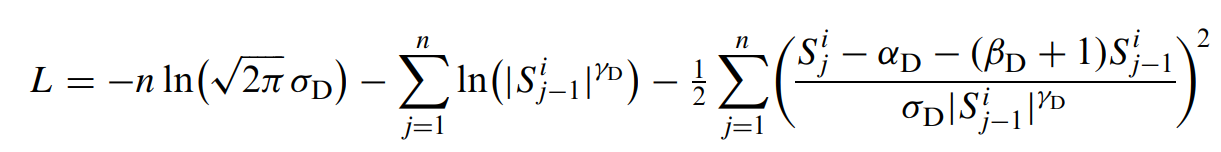

In [ ]:
spread_id = ["BAMLC0A0CM","BAMLC0A1CAAA","BAMLC0A2CAA","BAMLC0A3CA","BAMLC0A4CBBB"]
spread_dict = {"BAMLC0A0CM":"ICE_Bofa_US_Corp_OAS","BAMLC0A1CAAA":"ICE_Bofa_US_AAA_OAS","BAMLC0A2CAA":"ICE_Bofa_US_AA_OAS","BAMLC0A3CA":"ICE_Bofa_US_A_OAS","BAMLC0A4CBBB":"ICE_Bofa_US_BBB_OAS"}
df_spreads = fred_query(spread_id,spread_dict, "01-01-1990")
df_spreads.describe()

,ICE_Bofa_US_Corp_OAS,ICE_Bofa_US_AAA_OAS,ICE_Bofa_US_AA_OAS,ICE_Bofa_US_A_OAS,ICE_Bofa_US_BBB_OAS
count,7390.000000,7391.000000,7391.000000,7391.000000,7391.000000
mean,1.487543,0.758882,0.942124,1.264873,1.923104
std,0.825915,0.509332,0.644691,0.818589,1.003550
min,0.530000,0.190000,0.360000,0.480000,0.720000
25%,0.990000,0.570000,0.610000,0.820000,1.310000
50%,1.300000,0.640000,0.770000,1.040000,1.700000
75%,1.680000,0.790000,1.030000,1.395000,2.210000
max,6.560000,6.070000,5.150000,6.490000,8.040000


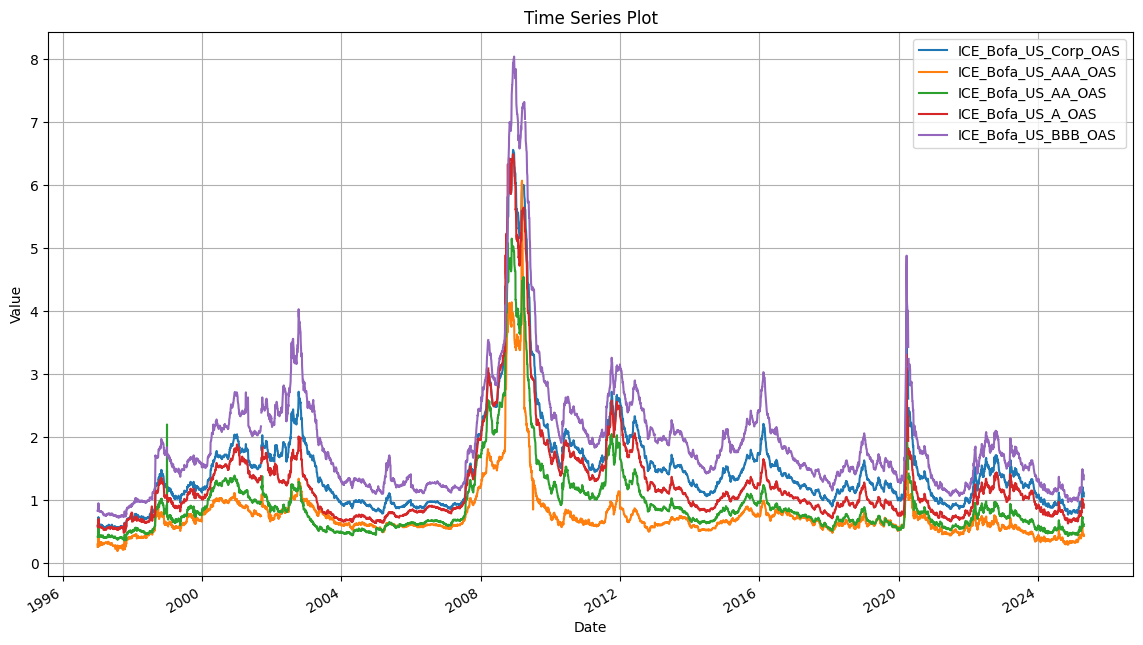

In [ ]:
# Plot
plt.figure(figsize=(14, 8))
df_spreads.plot(ax=plt.gca())
plt.title('Time Series Plot')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.legend(loc='best')
plt.show()

In [ ]:
spread_data = df_spreads['ICE_Bofa_US_BBB_OAS'].dropna().to_numpy()

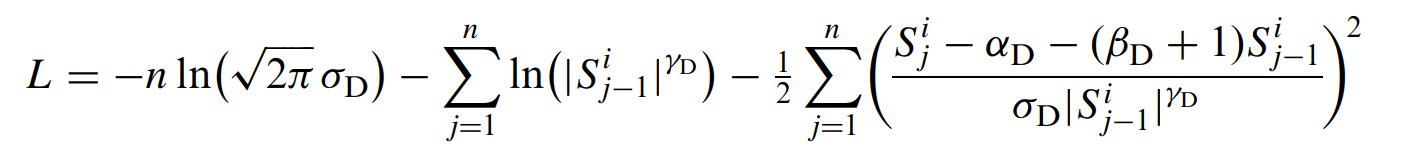

In [ ]:
def log_likelihood(params):
    #t1 = np.ones(len(spread_data))
    kappa, theta, sigma = params
    beta = -kappa
    alpha = kappa * theta

    gamma = 0.5
    n = len(spread_data) - 1  # because S[0] to S[n] -> n increments
    term1 = -n * np.log(np.sqrt(np.pi)*sigma)

    term2 = 0
    for t in range(n+1):
      term2 = term2 + np.log(np.abs(spread_data[t-1])**0.5)

    term3 = 0
    for t in range(n+1):
      term3 = term3 + ((spread_data[t]- alpha - (beta+1)*spread_data[t-1])/(sigma*(np.abs(spread_data[t-1])**0.5)))**2
      #t1[t]= ((spread_data[t]-alpha + (beta+1)*spread_data[t-1])/(sigma*(np.abs(spread_data[t-1])**0.5)))**2
    term3 = 0.5 * term3

    L = term1 - term2 - term3
    L = -L
    return L

BBB calibration

In [ ]:
spread_data = df_spreads['ICE_Bofa_US_BBB_OAS'].dropna().to_numpy()

bounds = [(1e-6, None),   # kappa
        (1e-6, None),   # theta
        (1e-6, None)]   # sigma

x0 = [0.01,2,0.04]           #x0 for BBB

result = minimize(log_likelihood, x0, tol = 1e-3, method='SLSQP', options={'maxiter': 1e4 }, bounds=bounds)
estimated_params = result.x
print(result)
opt_kappa = estimated_params[0]
opt_theta = estimated_params[1]
opt_sigma = estimated_params[2]

print(opt_kappa,opt_theta,opt_sigma)

/usr/local/lib/python3.11/dist-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -19165.706120202005
       x: [ 5.285e-04  1.967e+00  1.931e-02]
     nit: 19
     jac: [-7.014e+01  1.028e-01 -1.685e+02]
    nfev: 92
    njev: 18
0.0005284870733359274 1.9666276030657728 0.019313474437009627


AAA Calibration

In [ ]:
spread_data = df_spreads['ICE_Bofa_US_AAA_OAS'].dropna().to_numpy()

bounds = [(1e-3, 0.2),   # kappa
        (1e-6, 2),   # theta
        (1e-6, 0.2)]   # sigma

x0 = [0.1,0.7,0.04]           #x0 for BBB

result = minimize(log_likelihood, x0, tol = 1e-3, method='SLSQP', options={'maxiter': 1e4 }, bounds=bounds)
estimated_params = result.x
print(result)
opt_kappa = estimated_params[0]
opt_theta = estimated_params[1]
opt_sigma = estimated_params[2]

print(opt_kappa,opt_theta,opt_sigma)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -20279.422373334713
       x: [ 2.039e-03  7.589e-01  2.665e-02]
     nit: 22
     jac: [ 4.313e+00  1.611e-02  3.556e+00]
    nfev: 99
    njev: 20
0.002038508485538549 0.7588688695911578 0.026650812284845567


AA Calibration

In [ ]:
spread_data = df_spreads['ICE_Bofa_US_AA_OAS'].dropna().to_numpy()

bounds = [(1e-6, 0.4),   # kappa
        (1e-6, 5),   # theta
        (1e-6, 0.2)]   # sigma

x0 = [0.035,0.95,0.04]           #x0 for BBB

result = minimize(log_likelihood, x0, tol = 1e-3, method='SLSQP', options={'maxiter': 1e4 }, bounds=bounds)
estimated_params = result.x
print(result)
opt_kappa = estimated_params[0]
opt_theta = estimated_params[1]
opt_sigma = estimated_params[2]

print(opt_kappa,opt_theta,opt_sigma)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -19462.581486158506
       x: [ 2.009e-02  9.457e-01  2.370e-02]
     nit: 11
     jac: [ 5.739e+04  1.239e+03 -8.159e+04]
    nfev: 35
    njev: 7
0.020091368920023615 0.9456862938928676 0.023700708509117867


#####**Simulate process**

In [ ]:
def credit_spread_model_sim(kappa,theta,sigma,s0, T, N, M):
    # Initialise other parameters
    num_steps = N // T
    dt = T/N

    # Store rates
    s_path = np.full(shape=(N+1,M), fill_value=(s0))

    # Generate random numbers using numpy
    Z = np.random.normal(0, 1, (N, M))
    # Simulation loop

    for i in range(1, N + 1):
        # CIR Update for r1
        dr1 = kappa * (theta - s_path[i - 1]) * dt + sigma * np.sqrt(np.maximum(s_path[i - 1], 0)) * np.sqrt(dt) * Z[i - 1]
        s_path[i] = np.maximum(s_path[i - 1] + dr1, 0)  # Ensure positivity

    #Reduce the size of the array to year end values
    selected_indices  = [0] + list(range(int(N/T), s_path.T.shape[1], int(N/T)))  # 0 is initial, then every 252, and last
    reduced_s = s_path.T[:, selected_indices]

    return s_path.T, reduced_s

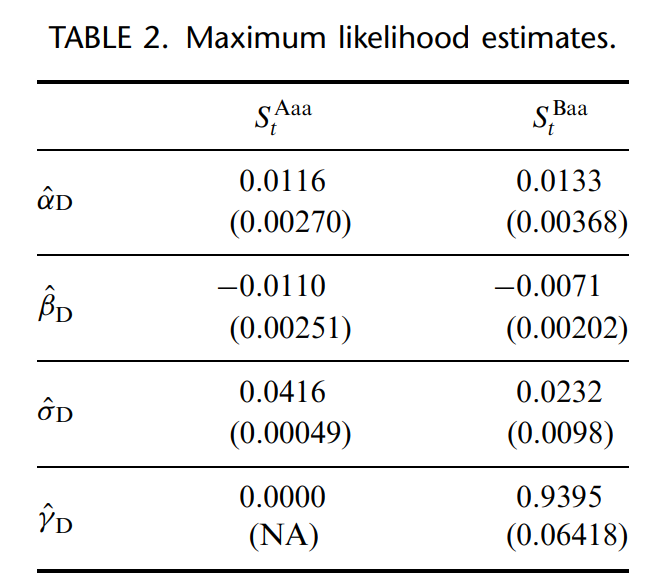

In [ ]:
T= 45
N = 252 * T
M = 10000
s0 = 0.0052
kappa = 0.020091368920023615
theta = 0.9456862938928676 * 0.01
sigma = 0.023700708509117867 *0.01 * 252**0.5        # Volatility

full_spreads, spreads = credit_spread_model_sim(kappa,theta,sigma,s0, T, N, M)

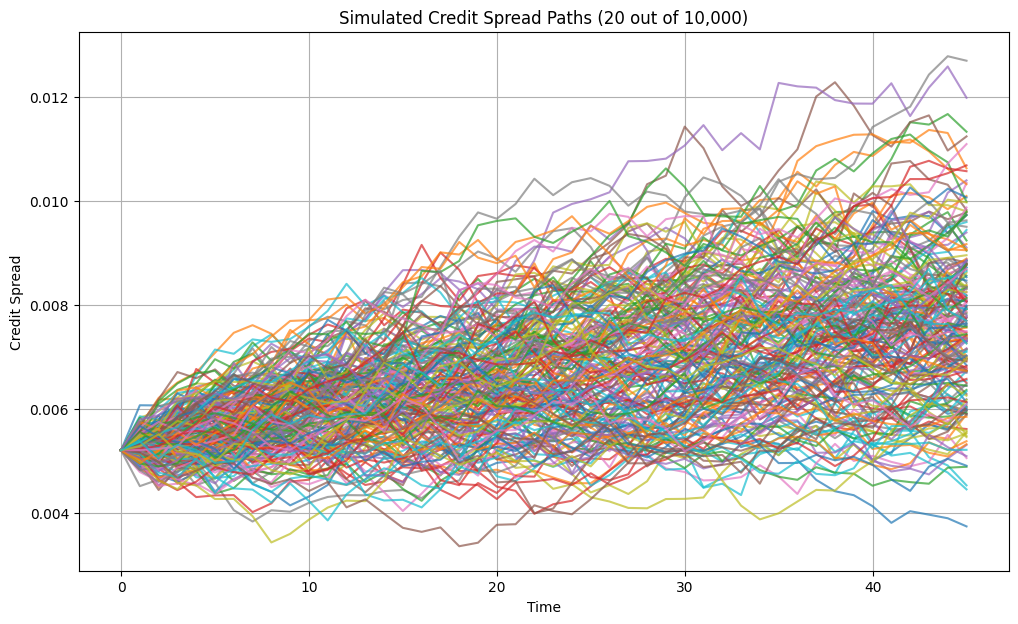

In [ ]:
# Example: Plot a few paths
plt.figure(figsize=(12, 7))
for i in range(200):  # Plot 20 random paths
    plt.plot(spreads[i], alpha=0.7)
plt.title("Simulated Credit Spread Paths (20 out of 10,000)")
plt.xlabel("Time")
plt.ylabel("Credit Spread")
plt.grid(True)
plt.show()

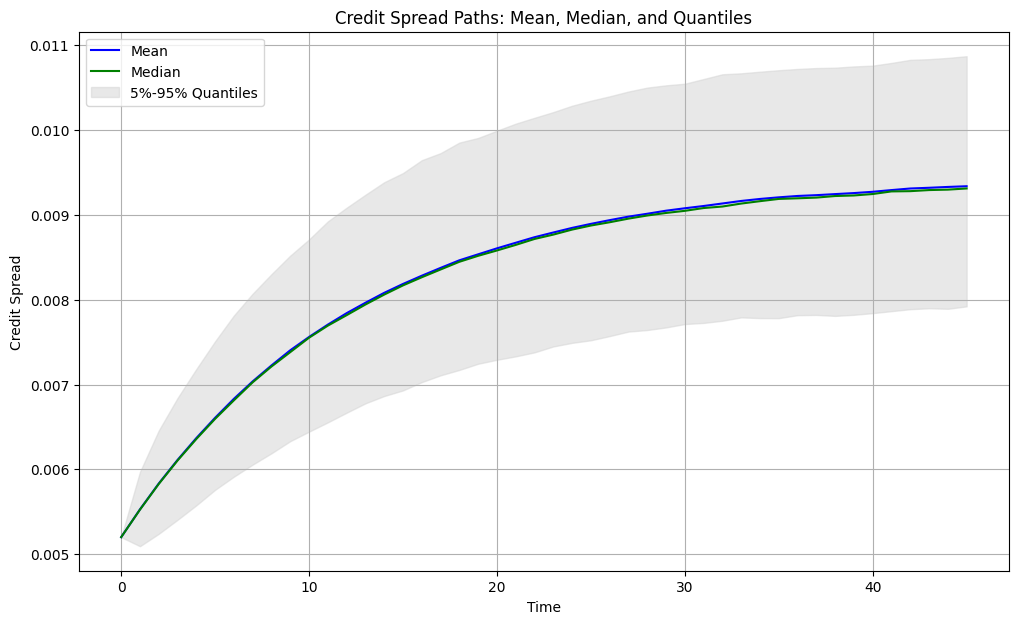

In [ ]:
# Calculate statistics across paths (axis=0 means across rows)
mean_spread = np.mean(spreads, axis=0)
median_spread = np.median(spreads, axis=0)
quantile_5 = np.quantile(spreads, 0.05, axis=0)
quantile_95 = np.quantile(spreads, 0.95, axis=0)

# Time axis
time = np.arange(spreads.shape[1])

# Plot
plt.figure(figsize=(12, 7))
plt.plot(time, mean_spread, label='Mean', color='blue')
plt.plot(time, median_spread, label='Median', color='green')
plt.fill_between(time, quantile_5, quantile_95, color='lightgrey', alpha=0.5, label='5%-95% Quantiles')
plt.title('Credit Spread Paths: Mean, Median, and Quantiles')
plt.xlabel('Time')
plt.ylabel('Credit Spread')
plt.legend()
plt.grid(True)
plt.show()

#####Create **random** numbers

In [ ]:
N = int(252) * 45
M = 10000

In [ ]:
mü = np.array([0,0])
rho = -0.48425872980352486
cov = np.array([[1,rho],[rho,1]])
Z = np.random.multivariate_normal(mü, cov, (N,M))

In [ ]:
correlation_matrix = np.corrcoef(Z.reshape(-1, 2), rowvar=False)
correlation_matrix

In [ ]:
# Given
rho_equity_vola = -0.48425872980352486    # correlation between equity and volatility
rho_equity_credit = -0.3                  # you specify this (example value)
rho_vola_credit = 0.67                    # you specify this (example value)

# Create 3x3 covariance matrix
cov = np.array([
    [1.0, rho_equity_vola, rho_equity_credit],
    [rho_equity_vola, 1.0, rho_vola_credit],
    [rho_equity_credit, rho_vola_credit, 1.0]
])

# Safety check: covariance matrix must be positive semi-definite
eigvals = np.linalg.eigvals(cov)
if np.all(eigvals >= 0):
    print("Covariance matrix is positive semi-definite ✅")
else:
    raise ValueError("Covariance matrix is NOT positive semi-definite ❌")

# Mean vector
mu = np.zeros(3)

# Simulate
Z = np.random.multivariate_normal(mu, cov, (N, M))  # shape: (N, M, 3)

# Result
Z_equity = Z[:, :, 0]
Z_volatility = Z[:, :, 1]
Z_credit = Z[:, :, 2]

Covariance matrix is positive semi-definite ✅


In [ ]:
for i in range(3):
    mean = np.mean(Z[:, :, i])
    std = np.std(Z[:, :, i])
    print(f"Variable {i} - mean: {mean:.5f}, std: {std:.5f}")

Variable 0 - mean: 0.00009, std: 0.99995
Variable 1 - mean: -0.00008, std: 1.00010
Variable 2 - mean: 0.00008, std: 1.00005


In [ ]:
correlation_matrix = np.corrcoef(Z.reshape(-1, 3), rowvar=False)
correlation_matrix

array([[ 1.        , -0.48416911, -0.30000374],
       [-0.48416911,  1.        ,  0.67002702],
       [-0.30000374,  0.67002702,  1.        ]])